# **Feature Engineering**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# **Fitur Handling Duplikat**

1. Saat kita ingin melihat ada atau tidaknya duplikat pada data, kita bisa melihat panjang baris dari data yang kita punya

In [5]:
df = pd.read_excel('titanic.xlsx')
print(df.head())

   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

       age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.0000      0      0   24160  211.3375       B5        S    2    NaN   
1   0.9167      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.0000      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4  25.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest  
0                     St 

In [6]:
len(df) #mengecek panjang baris dari df

1349

In [7]:
len(df) - len(df.drop_duplicates()) #mengecek selisih baris dari df dengan df yg telah dicoba drop duplikat

44

Pada kode (len(df) - len(df.drop_duplicates())), kita menghitung jumlah baris yang duplikat dengan "*menghitung seluruh jumlah baris dalam DataFrame (len(df)) dan menguranginya dengan jumlah baris setelah menghapus duplikat*" menggunakan metode drop_duplicates.

Ini menghitung semua duplikat di DataFrame.

In [8]:
len(df.drop_duplicates()) #mengecek panjang baris ketika sudah diperlakukan drop duplikat

1305

kita juga bisa melihat baris yang duplikat

In [9]:
len(df.drop_duplicates()) / len(df) #jika output dari code di cell ini tidak bernilai 1 maka terdapat duplikat

0.9673832468495182

In [7]:
# Menampilkan baris yang memiliki duplikat berdasarkan semua kolom, nanti hanya pilih 1 saja, karena yang duplikat hanya 44 baris
duplicates = df[df.duplicated(keep=False)]

print("Baris dengan duplikat:")
duplicates

Baris dengan duplikat:


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
104,1,1,"Eustis, Miss. Elizabeth Mussey",female,54.0,1,0,36947,78.2667,D20,C,4,NaN,"Brookline, MA"
349,1,1,"Eustis, Miss. Elizabeth Mussey",female,54.0,1,0,36947,78.2667,D20,C,4,NaN,"Brookline, MA"
388,2,1,"Davies, Mrs. John Morgan (Elizabeth Agnes Mary...",female,48.0,0,2,C.A. 33112,36.7500,NaN,S,14,NaN,"St Ives, Cornwall / Hancock, MI"
1048,3,0,"van Billiard, Mr. Austin Blyler",male,40.5,0,2,A/5. 851,14.5000,NaN,S,NaN,255.0,NaN
1049,3,0,"Van Impe, Miss. Catharina",female,10.0,0,2,345773,24.1500,NaN,S,NaN,NaN,NaN
1050,3,0,"Van Impe, Mr. Jean Baptiste",male,36.0,1,1,345773,24.1500,NaN,S,NaN,NaN,NaN
1051,3,0,"Van Impe, Mrs. Jean Baptiste (Rosalie Paula Go...",female,30.0,1,1,345773,24.1500,NaN,S,NaN,NaN,NaN
1265,3,0,"van Billiard, Mr. Austin Blyler",male,40.5,0,2,A/5. 851,14.5000,NaN,S,NaN,255.0,NaN
1266,3,0,"Van Impe, Miss. Catharina",female,10.0,0,2,345773,24.1500,NaN,S,NaN,NaN,NaN
1267,3,0,"Van Impe, Mr. Jean Baptiste",male,36.0,1,1,345773,24.1500,NaN,S,NaN,NaN,NaN


In [10]:
df = df.drop_duplicates() #drop duplikat

In [11]:
#mengecek selisih baris dari df dengan df yg telah dicoba drop duplikat
len(df) - len(df.drop_duplicates())

0

In [12]:
len(df.drop_duplicates()) / len(df)
#jika output dari code di cell ini tidak bernilai 1 maka terdapat duplikat

1.0

kita sudah handling drop duplikat

Drop duplikat **SELESAI**

# **Outlier Handling**

Outlier adalah data yang sangat aneh dibandingkan dengan data lainnya, hingga menimbulkan kecurigaan bahwa data tersebut berasal dari sumber yang berbeda. Hal ini dapat memengaruhi statistik seperti:
* rata-rata dan varians,
* kinerja beberapa model Machine Learning.

Oleh karena itu, tergantung pada algoritma yang digunakan, seringkali diperlukan tindakan untuk mengatasi outlier dengan menghapus atau memprosesnya. Ada 2 cara yang umum dipakai untuk handling outlier :
1.   IQR : Interquartile (Pendekatan Statistik)
2.  Nilai Sembarang : (Pendekatan Bisnis)



## 1. Outlier Handling : InterQuartile Handling

In [13]:
import pandas as pd

In [14]:
# untuk plot Q-Q
import scipy.stats as stats

In [15]:
df_california = pd.read_csv('california_dataset.csv')
df_california.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,house_price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# spliting data

In [16]:
from sklearn.model_selection import train_test_split
train_clfr, test_clfr = train_test_split(df_california, test_size = 0.2, random_state=42)
#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

In [17]:
df_california.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'house_price'],
      dtype='object')

Disini kita visualisasikan kolom pada data df_california dalam bentuk:
1. histogram
2. plot Q-Q
3. box plot

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
def check_plot(df, variable):
    # fungsi mengambil kerangka data (df) dan
    # variabel yang diminati sebagai argumen

    # tentukan ukuran gambar
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')

    # plot Q-Q
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

Disini saya mengambil contoh pada kolom "Population" untuk divisualisasikan

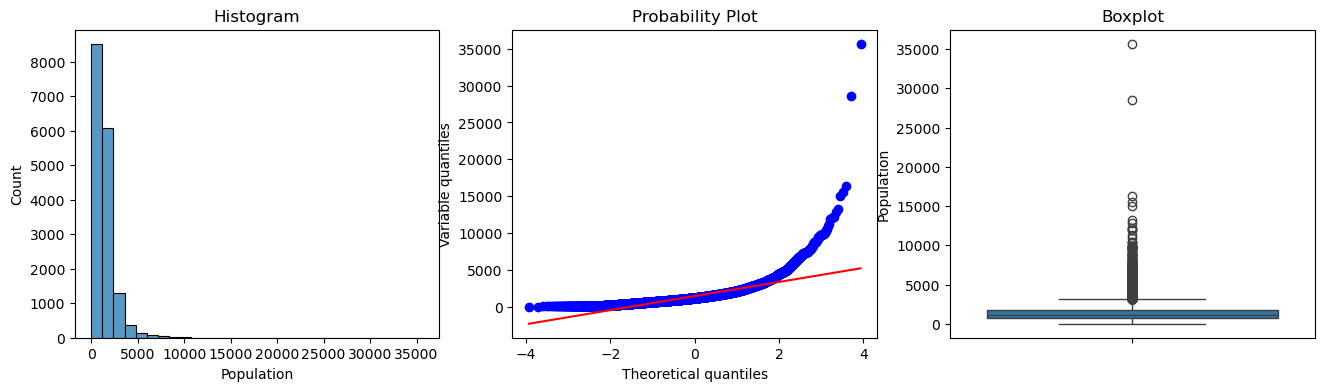

In [19]:
check_plot(train_clfr, 'Population')

Dari visualisasi kolom "population" terlihat bahwa ada outlier pada kolom tersebut. Terlihat dari visualisasi yang ditampilkan:
1. Histogram : Sebagian besar data berkumpul di nilai kecil (sebelah kiri), dengan ekor panjang di sisi kanan (skew kanan).
2. Probabilit plot : terlihat titik biru yang berada diluar garis merah, yang menandakan adanya outlier
3. boxplot : Banyak outlier di sisi atas.
Whisker bawah pendek, sedangkan whisker atas panjang.

In [20]:
def find_outlier_boundary(df, variable):

    # Mari kita hitung batas luar yang merupakan outlier

    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)

    lower_boundary = df[variable].quantile(0.25) - (IQR * 1.5)
    upper_boundary = df[variable].quantile(0.75) + (IQR * 1.5)

    return upper_boundary, lower_boundary

In [21]:
Population_upper_limit, Population_lower_limit = find_outlier_boundary(train_clfr, 'Population')
Population_upper_limit, Population_lower_limit

(np.float64(3131.5), np.float64(-616.5))



*   Upper Limit (3131.5) → Nilai di atas ini dianggap sebagai outlier.
*   Lower Limit (-616.5) → Nilai di bawah ini juga dianggap sebagai outlier.



In [21]:
import numpy as np

In [22]:
# Sekarang mari kita ganti outlier dengan batas maksimum dan minimum

train_clfr['Population'] = np.where(
    train_clfr['Population'] > Population_upper_limit, Population_upper_limit,  # Jika lebih besar dari batas atas, ganti dengan batas atas
    np.where(
        train_clfr['Population'] < Population_lower_limit, Population_lower_limit,  # Jika lebih kecil dari batas bawah, ganti dengan batas bawah
        train_clfr['Population']  # Jika tidak outlier, biarkan tetap sama
    )
)

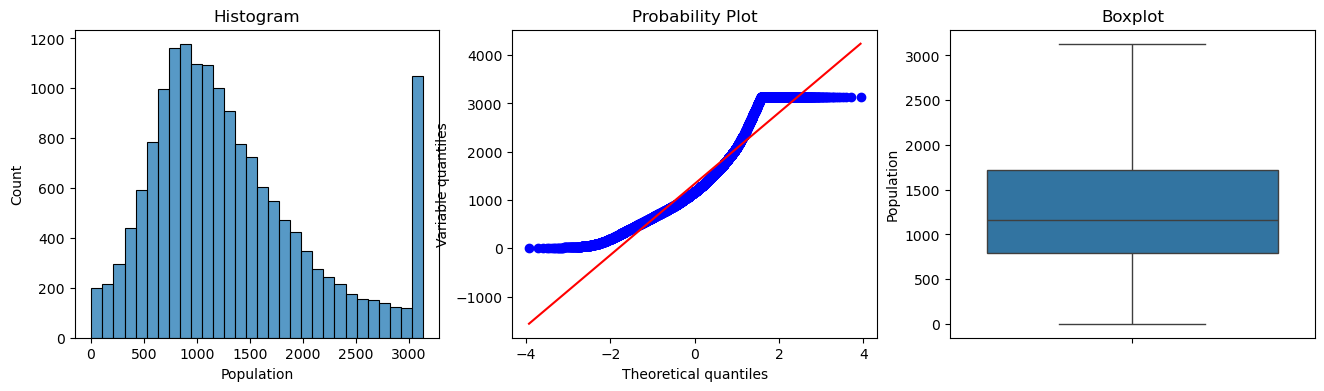

In [23]:
# memvisualisasikan outlier
check_plot(train_clfr, 'Population')

Dari distribusi diatas, kita bisa melihat tidak skew kanan yang extreme, melainkan ada 1 nilai di sebelah kanan yang menumpuk akibat handling IQR namun hal ini valid secara statistik. Boxplot pun hilang karena pengaruh IQR ini.

## 2. Outlier Handling : Nilai Sembarang (Business Perspective)

disini kita menggunakan data titanic

In [24]:
!pip install feature_engine

Defaulting to user installation because normal site-packages is not writeable


In [24]:
from feature_engine.outliers import ArbitraryOutlierCapper

In [25]:
from sklearn.model_selection import train_test_split
train_titanic, test_titanic = train_test_split(df, test_size = 0.2, random_state=42)
#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

In [26]:
df.columns

Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'],
      dtype='object')

In [27]:
train_titanic.age.describe()

count    835.000000
mean      29.932335
std       14.133864
min        0.166700
25%       21.000000
50%       28.000000
75%       38.500000
max       80.000000
Name: age, dtype: float64

Misal : karena alasan keselamatan dan tanggung jawab bersama maka, ada aturan di kapal titanic bahwa anak-anak dibawah 3 tahun dilarang naik kapal, minimal harus 3 tahun dan maksimal umur 80 tahun.

In [28]:
teknik_capper = ArbitraryOutlierCapper(max_capping_dict={'age': 80},
                                       min_capping_dict={'age': 3})

teknik_capper.fit(train_titanic.fillna(0))
#Dokumentasi : https://feature-engine.trainindata.com/en/1.1.x/outliers/ArbitraryOutlierCapper.html
#asumsikan sudah dilakukan handling missing value dengan teknik sementara yaitu memasukkan nilai 0,
#(nanti nilainya bisa disesuaikan menggunakan median misalnya karena numerikal)
#jika tidak demikian maka .fit akan error karena ada NaN atau nilai null lainnya

,max_capping_dict,{'age': 80}
,min_capping_dict,{'age': 3}
,missing_values,'raise'


In [29]:
temp_titanic = teknik_capper.transform(train_titanic.fillna(0))

In [30]:
temp_titanic.age.describe()

count    1044.000000
mean       24.584291
std        16.553484
min         3.000000
25%         8.000000
50%        24.250000
75%        35.000000
max        80.000000
Name: age, dtype: float64

Dari describe diatas kita bisa melihat bahwa nilai minimalnya 3 tahun dan maksimalnya 80 tahun.

# **Missing Value Handling**

In [31]:
df_company = pd.read_csv('company.csv')

In [32]:
df_company.head()

,Revenue,Size,Rating,Headquarters
0,Unknown / Non-Applicable,1001 to 5000 employees,3.1,"New York, NY"
1,$1 to $2 billion (USD),5001 to 10000 employees,4.2,"Herndon, VA"
2,$100 to $500 million (USD),1001 to 5000 employees,3.8,"Boston, MA"
3,$100 to $500 million (USD),501 to 1000 employees,3.5,"Bad Ragaz, Switzerland"
4,Unknown / Non-Applicable,51 to 200 employees,2.9,"New York, NY"


In [33]:
df_company.isna().sum()

Revenue         0
Size            0
Rating          0
Headquarters    0
dtype: int64

Apakah benar tidak ada missing value ?

In [34]:
for column in df_company.columns:
    print(f"============= {column} =================")
    display(df_company[column].value_counts())
    print()

============= Revenue =================


Revenue
Unknown / Non-Applicable            213
$100 to $500 million (USD)           94
$10+ billion (USD)                   63
$2 to $5 billion (USD)               45
$10 to $25 million (USD)             41
$1 to $2 billion (USD)               36
$25 to $50 million (USD)             36
$50 to $100 million (USD)            31
$1 to $5 million (USD)               31
-1                                   27
$500 million to $1 billion (USD)     19
$5 to $10 million (USD)              14
Less than $1 million (USD)           14
$5 to $10 billion (USD)               8
Name: count, dtype: int64


============= Size =================


Size
51 to 200 employees        135
1001 to 5000 employees     104
1 to 50 employees           86
201 to 500 employees        85
10000+ employees            80
501 to 1000 employees       77
5001 to 10000 employees     61
-1                          27
Unknown                     17
Name: count, dtype: int64


============= Rating =================


Rating
 3.5    58
-1.0    50
 4.0    41
 3.3    41
 3.9    40
 3.8    39
 3.7    38
 5.0    36
 4.5    32
 3.6    31
 3.4    31
 4.2    29
 4.1    25
 4.4    24
 4.7    22
 3.2    21
 4.8    20
 4.3    14
 2.9    14
 4.6    12
 3.1    12
 4.9    11
 2.7    10
 3.0     7
 2.6     4
 2.8     3
 2.5     2
 2.2     1
 2.4     1
 2.3     1
 2.1     1
 2.0     1
Name: count, dtype: int64


============= Headquarters =================


Headquarters
New York, NY                 33
-1                           31
San Francisco, CA            31
Chicago, IL                  23
Boston, MA                   19
Reston, VA                   14
Mc Lean, VA                  13
Westminster, CO              12
Cambridge, United Kingdom    10
Cambridge, MA                10
Vienna, VA                    8
Denver, CO                    7
Herndon, VA                   7
Washington, DC                7
Woodbine, MD                  7
Saint Louis, MO               7
Bedford, MA                   7
Arlington, VA                 7
San Jose, CA                  7
San Antonio, TX               6
Mountain View, CA             6
Basel, Switzerland            6
San Rafael, CA                6
Chantilly, VA                 6
Fairfax, VA                   5
Houston, TX                   5
Pittsburgh, PA                5
Bethesda, MD                  5
Rockville, MD                 5
Los Angeles, CA               5
Springfield, MA            

Ternyata terdapat nilai missing value di ketiga kolom itu :
- Rating: -1
- Size: -1, Unknown
- Revenue: -1, Unknown / Non-Applicable


Lalu kita akan cek berapa masing-masing kolom memiliki persentase missing value, dalam statistik ketentuannya ialah **jika diatas 20% maka kita drop kolomnya**, **jika <= 20% maka di handling karena alasan distribusi data**.

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [35]:
100 * len(df_company[df_company['Rating']==-1]) / len(df_company) #untuk menghitung persentase data dengan nilai Rating = -1 dalam dataset

7.440476190476191

In [36]:
100 * len(df_company[df_company['Size'].isin(['-1','Unknown'])]) / len(df_company) #Menghitung persentase data yang kolom Size-nya bernilai '-1' atau 'Unknown'

6.5476190476190474

In [37]:
100 * len(df_company[df_company['Revenue'].isin(['-1','Unknown / Non-Applicable'])]) / len(df_company)

35.714285714285715

Kita akan drop kolom Revenue karena diatas 20% nilai missing kolomnya.

In [38]:
df_company = df_company.drop(columns=['Revenue'])
df_company.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Size          672 non-null    object 
 1   Rating        672 non-null    float64
 2   Headquarters  672 non-null    object 
dtypes: float64(1), object(2)
memory usage: 15.9+ KB


Untuk kolom Rating disini kita akan melakukan handling dengan menggunakan **median**

In [39]:
from sklearn.model_selection import train_test_split
train_company, test_company = train_test_split(df_company, test_size = 0.2, random_state=42)

In [40]:
# Imputasi median pada kolom Rating : train

median_rating_train = train_company[train_company['Rating']!=-1]['Rating'].median()

Mencari nilai **median** dari kolom **Rating** tanpa memasukkan nilai -1 (karena -1 digunakan sebagai penanda nilai yang hilang).
Hasilnya disimpan dalam **median_rating_train**, yang akan digunakan untuk menggantikan nilai -1.

In [41]:
median_rating_train

3.8

In [42]:
#menerapkan imputasi nilai yang hilang untuk melatih dan menguji, dari pemeringkatan nilai median dalam data train
train_company['Rating'] = train_company['Rating'].apply(lambda x: median_rating_train if x==-1 else x) #train
test_company['Rating'] = test_company['Rating'].apply(lambda x: median_rating_train if x==-1 else x) #test

Mengganti semua nilai -1 dalam Rating dengan nilai median_rating_train baik untuk train maupun test.

In [43]:
train_company['Rating'].value_counts()

Rating
3.8    72
3.5    47
3.3    35
4.0    34
3.9    33
5.0    31
3.7    28
4.5    25
3.6    25
3.4    23
4.1    21
4.2    21
4.4    19
4.8    17
4.7    17
3.2    17
4.3    11
2.7    10
4.6    10
3.1     9
2.9     9
4.9     9
2.6     3
3.0     3
2.8     2
2.0     1
2.3     1
2.1     1
2.5     1
2.2     1
2.4     1
Name: count, dtype: int64

* Setelah imputasi, nilai -1 sudah tidak ada lagi di train_company['Rating'].
* Median dari train kan 3.8, sehingga semua nilai -1 diubah menjadi 3.8.
* Karena ada banyak nilai -1 yang diubah menjadi 3.8, maka frekuensi 3.8 meningkat drastis menjadi 72.
* Nilai-nilai lain tetap memiliki distribusi aslinya karena tidak berubah.

# **Encoding**

Untuk membaca jenis data dari tiap kolom kita bisa panggil dengan df_churn.info()

In [44]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')
df_churn.head(6)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes


In [45]:
# Mengganti "Yes" menjadi 1 dan "No" menjadi 0 dalam kolom "Churn"
df_churn['Churn'] = df_churn['Churn'].replace({'Yes': 1, 'No': 0})
df_churn.head()

C:\Users\Neosia\AppData\Local\Temp\ipykernel_41004\2847510434.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_churn['Churn'] = df_churn['Churn'].replace({'Yes': 1, 'No': 0})


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [46]:
#Cek nilai-nilai di kolom kategorikal
custom_columns = ['gender','Partner','Dependents','PhoneService','MultipleLines',
                  'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection'
                  ,'TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod','Churn']
for column in custom_columns:
    print(f"============= {column} =================")
    display(df_churn[column].value_counts())
    print()

============= gender =================


gender
Male      3555
Female    3488
Name: count, dtype: int64


============= Partner =================


Partner
No     3641
Yes    3402
Name: count, dtype: int64


============= Dependents =================


Dependents
No     4933
Yes    2110
Name: count, dtype: int64


============= PhoneService =================


PhoneService
Yes    6361
No      682
Name: count, dtype: int64


============= MultipleLines =================


MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


============= InternetService =================


InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


============= OnlineSecurity =================


OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


============= OnlineBackup =================


OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64


============= DeviceProtection =================


DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64


============= TechSupport =================


TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64


============= StreamingTV =================


StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64


============= StreamingMovies =================


StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64


============= Contract =================


Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


============= PaperlessBilling =================


PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64


============= PaymentMethod =================


PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


============= Churn =================


Churn
0    5174
1    1869
Name: count, dtype: int64

Jika teman-teman lihat, ada beberapa kolom memiliki nilai 'No internet service' atau 'No phone service', yang artinya pelanggan tidak memiliki layanan tersebut.
Untuk menyederhanakan data, nilai 'No internet service' diubah menjadi 'No' dalam fitur layanan internet.

In [47]:
df_churn['StreamingMovies'] = df_churn['StreamingMovies'].replace({'No internet service':'No'})
df_churn['StreamingTV'] = df_churn['StreamingTV'].replace({'No internet service':'No'})
df_churn['TechSupport'] = df_churn['TechSupport'].replace({'No internet service':'No'})
df_churn['DeviceProtection'] = df_churn['DeviceProtection'].replace({'No internet service':'No'})
df_churn['OnlineBackup'] = df_churn['OnlineBackup'].replace({'No internet service':'No'})
df_churn['OnlineSecurity'] = df_churn['OnlineSecurity'].replace({'No internet service':'No'})
df_churn['MultipleLines'] = df_churn['MultipleLines'].replace({'No phone service':'No'})

In [48]:
#Cek nilai-nilai di kolom kategorikal
for column in custom_columns:
    print(f"============= {column} =================")
    display(df_churn[column].value_counts())
    print()

============= gender =================


gender
Male      3555
Female    3488
Name: count, dtype: int64


============= Partner =================


Partner
No     3641
Yes    3402
Name: count, dtype: int64


============= Dependents =================


Dependents
No     4933
Yes    2110
Name: count, dtype: int64


============= PhoneService =================


PhoneService
Yes    6361
No      682
Name: count, dtype: int64


============= MultipleLines =================


MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64


============= InternetService =================


InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


============= OnlineSecurity =================


OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64


============= OnlineBackup =================


OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64


============= DeviceProtection =================


DeviceProtection
No     4621
Yes    2422
Name: count, dtype: int64


============= TechSupport =================


TechSupport
No     4999
Yes    2044
Name: count, dtype: int64


============= StreamingTV =================


StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64


============= StreamingMovies =================


StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64


============= Contract =================


Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


============= PaperlessBilling =================


PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64


============= PaymentMethod =================


PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


============= Churn =================


Churn
0    5174
1    1869
Name: count, dtype: int64

## **One Hot Encoding**

In [49]:
train_churn, test_churn = train_test_split(df_churn, test_size = 0.2, random_state = 42)

In [50]:
# Melakukan one-hot encoding pada kolom "gender"
# Kolom-kolom yang ingin di one-hot encoding
encode_ohe = ['gender'] #buat list nama-nama kolom yang ingin dilakukan OHE
train_churn = pd.get_dummies(train_churn, columns=encode_ohe, dtype=int)
test_churn = pd.get_dummies(test_churn, columns=encode_ohe, dtype=int)

In [51]:
train_churn.head()

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male
2142,4223-BKEOR,0,No,Yes,21,Yes,No,DSL,Yes,No,Yes,No,No,Yes,One year,No,Mailed check,64.85,1336.8,0,1,0
1623,6035-RIIOM,0,No,No,54,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),97.20,5129.45,0,1,0
6074,3797-VTIDR,0,Yes,No,1,No,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,23.45,23.45,1,0,1
1362,2568-BRGYX,0,No,No,4,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.20,237.95,1,0,1
6754,2775-SEFEE,0,No,Yes,0,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,,0,0,1


In [52]:
test_churn.head()

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male
185,1024-GUALD,0,Yes,No,1,No,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,1,1,0
2715,0484-JPBRU,0,No,No,41,Yes,Yes,No,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,0,0,1
3825,3620-EHIMZ,0,Yes,Yes,52,Yes,No,No,No,No,No,No,No,No,Two year,No,Mailed check,19.35,1031.7,0,1,0
1807,6910-HADCM,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,1,1,0
132,8587-XYZSF,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,0,0,1


## **Label Encoder**

In [53]:
from sklearn.preprocessing import LabelEncoder

# Kolom-kolom yang ingin di-label encode
columns_to_encode = ['Partner', 'Dependents']

# Inisialisasi LabelEncoder
label_encoder = LabelEncoder()

In [54]:
# Menerapkan label encoding ke data pelatihan (train)
for col in columns_to_encode:
    train_churn[col] = label_encoder.fit_transform(train_churn[col])
#fit dilakukan di data train dan implementasikan ke train, kemudian lakukan transform ke data test Untuk mencegah data leakage

In [55]:
# Menerapkan label encoding yang sama ke data uji (test)
for col in columns_to_encode:
    test_churn[col] = label_encoder.transform(test_churn[col])

In [56]:
train_churn.head()

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male
2142,4223-BKEOR,0,0,1,21,Yes,No,DSL,Yes,No,Yes,No,No,Yes,One year,No,Mailed check,64.85,1336.8,0,1,0
1623,6035-RIIOM,0,0,0,54,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),97.20,5129.45,0,1,0
6074,3797-VTIDR,0,1,0,1,No,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,23.45,23.45,1,0,1
1362,2568-BRGYX,0,0,0,4,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.20,237.95,1,0,1
6754,2775-SEFEE,0,0,1,0,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,,0,0,1


In [57]:
test_churn.head()

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male
185,1024-GUALD,0,1,0,1,No,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,1,1,0
2715,0484-JPBRU,0,0,0,41,Yes,Yes,No,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,0,0,1
3825,3620-EHIMZ,0,1,1,52,Yes,No,No,No,No,No,No,No,No,Two year,No,Mailed check,19.35,1031.7,0,1,0
1807,6910-HADCM,0,0,0,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,1,1,0
132,8587-XYZSF,0,0,0,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,0,0,1


# **Feature Scalling**

Proses perubahan nilai skala dengan pendekatan statistik, dengan mengubah nilai tapi tidak mengubah makna. Tekniknya :

1. StandarScaller
2. MinMaxScaller

Notes :
Pada pembahasan ini, akan dilakukan pada kolom yang sama bertujuan untuk melakukan cara penggunaan libraries nya saja. Pada kolom : ['tenure', 'MonthlyCharges']

## 1. StandarScaler

In [58]:
from sklearn.preprocessing import StandardScaler

# Kolom-kolom yang ingin di-standarisasi
columns_to_stdscaller = ['tenure', 'MonthlyCharges']

# Inisialisasi StandardScaler
scaler = StandardScaler()

In [59]:
train_churn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 2142 to 860
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   int64  
 3   Dependents        5634 non-null   int64  
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5634 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 
 17

In [60]:
# Menerapkan standarisasi ke data pelatihan (train)
# Convert 'tenure' and 'MonthlyCharges' to numeric if they are datetime objects
train_churn['tenure'] = pd.to_numeric(train_churn['tenure'], errors='coerce')
train_churn['MonthlyCharges'] = pd.to_numeric(train_churn['MonthlyCharges'], errors='coerce')
train_churn[['tenure_stds', 'MonthlyCharges_stds']] = scaler.fit_transform(train_churn[columns_to_stdscaller])

# Menerapkan standarisasi yang sama ke data uji (test)
# Convert 'tenure' and 'MonthlyCharges' to numeric if they are datetime objects
test_churn['tenure'] = pd.to_numeric(test_churn['tenure'], errors='coerce')
test_churn['MonthlyCharges'] = pd.to_numeric(test_churn['MonthlyCharges'], errors='coerce')
test_churn[['tenure_stds', 'MonthlyCharges_stds']] = scaler.transform(test_churn[columns_to_stdscaller])

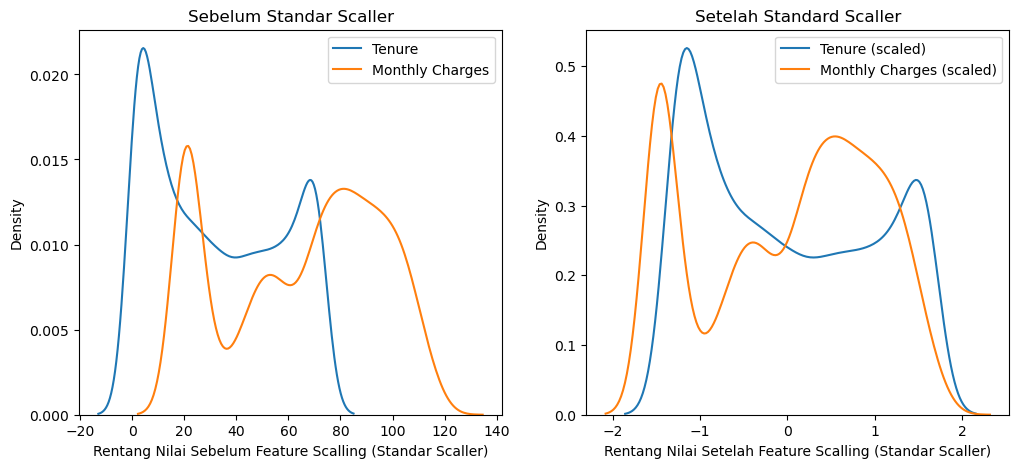

In [61]:
# kita lihat distribusi dari variabel sebelum standar scaller dan setelah standar scaller

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Standar Scaler
ax1.set_title('Sebelum Standar Scaller')
sns.kdeplot(train_churn['tenure'], ax=ax1, label='Tenure')
sns.kdeplot(train_churn['MonthlyCharges'], ax=ax1, label='Monthly Charges')

# Plot distribusi setelah Standar Scaler
ax2.set_title('Setelah Standard Scaller')
sns.kdeplot(train_churn['tenure_stds'], ax=ax2, label='Tenure (scaled)')
sns.kdeplot(train_churn['MonthlyCharges_stds'], ax=ax2, label='Monthly Charges (scaled)')

# Set x-labels
ax1.set_xlabel('Rentang Nilai Sebelum Feature Scalling (Standar Scaller)')
ax2.set_xlabel('Rentang Nilai Setelah Feature Scalling (Standar Scaller)')

# Menampilkan legenda
ax1.legend()
ax2.legend()

plt.show()

## 2. MinMaxScaler

In [62]:
from sklearn.preprocessing import MinMaxScaler

# Kolom-kolom yang ingin dinormalisasi
columns_to_normalize = ['tenure', 'MonthlyCharges']

# Inisialisasi MinMaxScaler
minmax = MinMaxScaler()

In [63]:
# Menerapkan normalisasi Min-Max ke data pelatihan (train)
train_churn[['tenure_minmax', 'MonthlyCharges_minmax']] = minmax.fit_transform(train_churn[columns_to_normalize])

# Menerapkan normalisasi Min-Max yang sama ke data uji (test)
test_churn[['tenure_minmax', 'MonthlyCharges_minmax']] = minmax.transform(test_churn[columns_to_normalize])

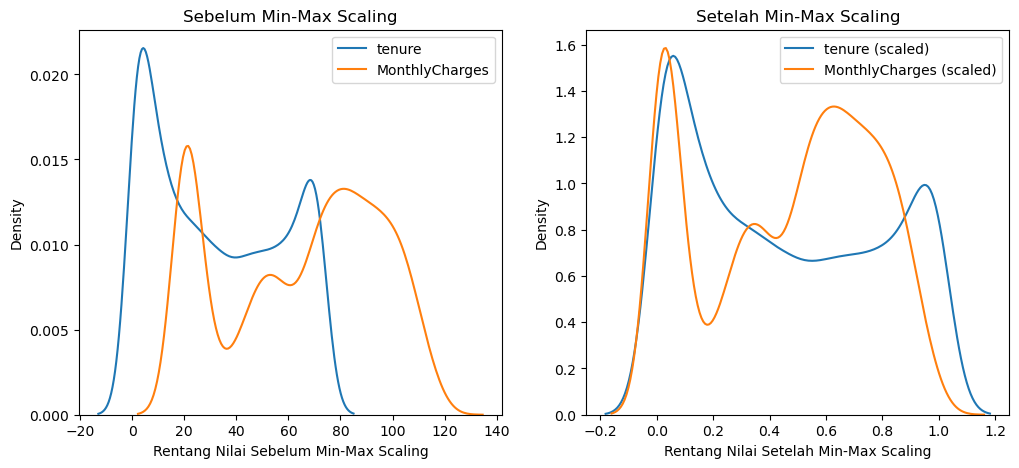

In [64]:
# Plot distribusi sebelum dan sesudah Min-Max Scaling
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Min-Max Scaling
ax1.set_title('Sebelum Min-Max Scaling')
sns.kdeplot(train_churn['tenure'], ax=ax1, label='tenure')
sns.kdeplot(train_churn['MonthlyCharges'], ax=ax1, label='MonthlyCharges')

# Plot distribusi setelah Min-Max Scaling
ax2.set_title('Setelah Min-Max Scaling')
sns.kdeplot(train_churn['tenure_minmax'], ax=ax2, label='tenure (scaled)')
sns.kdeplot(train_churn['MonthlyCharges_minmax'], ax=ax2, label='MonthlyCharges (scaled)')

# Set x-labels
ax1.set_xlabel('Rentang Nilai Sebelum Min-Max Scaling')
ax2.set_xlabel('Rentang Nilai Setelah Min-Max Scaling')

# Menampilkan legenda
ax1.legend()
ax2.legend()

plt.show()

In [65]:
train_churn[['tenure_minmax','MonthlyCharges_minmax']].describe()

,tenure_minmax,MonthlyCharges_minmax
count,5634.000000,5634.000000
mean,0.449626,0.464517
std,0.339230,0.299844
min,0.000000,0.000000
25%,0.125000,0.174390
50%,0.402778,0.520927
75%,0.763889,0.714375
max,1.000000,1.000000


## Selesai